# Step 4 Synthetic Experiments / Step 4 合成数据实验

This notebook runs the Step 4 synthetic experiments, saves artifacts, and checks whether the current run meets the Step 4 targets.
本 notebook 用于运行 Step 4 合成数据实验、保存结果，并检查当前运行是否达到 Step 4 目标。

**Workflow / 流程**
1. Configure paths, imports, and plotting defaults. / 配置路径、导入依赖并设置绘图风格。
2. Select a training preset and build experiment arguments. / 选择训练预设并生成实验参数。
3. Run E1a, E1b, and optionally E1c. / 运行 E1a、E1b，并按需运行 E1c。
4. Load summaries, compare against thresholds, and inspect figures. / 读取汇总结果、对照阈值，并检查图表。

**Training Presets / 训练预设**

| Plan | Epochs | Patience | Log Every | Usage |
| --- | ---: | ---: | ---: | --- |
| quick_check | 3 | 1 | 1 | Fast smoke test / 快速冒烟验证 |
| notebook_medium | 30 | 8 | 5 | Standard notebook run / notebook 标准实验 |
| formal_target | 200 | 20 | 10 | Formal target run / 正式实验配置 |

**Pass Criteria / 达标标准**

| Experiment | Metrics | Threshold |
| --- | --- | --- |
| E1a linear | kstar_mae, kstar_spearman_rho | kstar_mae < 1.0 and kstar_spearman_rho > 0.8 |
| E1b identification | proxy_recon_r2, z_spearman_rho | proxy_recon_r2 > 0.5 and z_spearman_rho > 0.8 |
| E1c nonlinear | kstar_mae, kstar_spearman_rho | kstar_mae < 1.0 and kstar_spearman_rho > 0.8 |

The default active plan below is notebook_medium. Change it to formal_target only when you want the full Step 4 run.
下面默认激活的是 notebook_medium；只有在你要执行完整 Step 4 正式实验时，再切换到 formal_target。

In [8]:
from pathlib import Path
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# Discover the repository root from the current working directory. / 从当前工作目录向上查找仓库根目录。
current = Path.cwd().resolve()
repo_root = next(
    (
        path
        for path in [current, *current.parents]
        if (path / "config").exists() and (path / "data").exists() and (path / "experiments").exists()
    ),
    None,
)

if repo_root is None:
    raise RuntimeError(f"Could not find repo root from {current}")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

# Use a consistent plotting style for experiment figures. / 统一实验图像的绘图风格。
plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 200)

print(f"repo_root = {repo_root}")

repo_root = C:\DevSpace\PyDevspace\CMDL


In [9]:
from argparse import Namespace

import numpy as np

from experiments.run_synthetic import run_e1a, run_e1b, run_e1c
from visualization.kstar_distribution import plot_kstar_scatter
from visualization.omega_heatmap import plot_omega_heatmap

PRESET_CONFIGS = {
    "quick_check": {"epochs": 3, "patience": 1, "log_every": 1},
    "notebook_medium": {"epochs": 30, "patience": 8, "log_every": 5},
    "formal_target": {"epochs": 200, "patience": 20, "log_every": 10},
}

ACTIVE_PLAN = "notebook_medium"
RUN_LINEAR = True
RUN_NONLINEAR = True
OUTPUT_DIR = repo_root / "outputs" / "notebook_step4" / ACTIVE_PLAN

# Keep shared experiment parameters in one place so plan switches are isolated. / 统一维护共享实验参数，切换计划时只改一个位置。
COMMON_ARGS = {
    "scenario": "all",
    "seed": 42,
    "lr": 1e-3,
    "lambda_r": 0.1,
    "temperature": 1.0,
    "lag_bias_strength": 1.0,
    "grad_clip": 1.0,
    "val_fraction": 0.2,
    "device": "auto",
    "disable_mlflow": False,
}

EXPERIMENT_ARGS = {
    **COMMON_ARGS,
    **PRESET_CONFIGS[ACTIVE_PLAN],
    "output_dir": str(OUTPUT_DIR),
}

args = Namespace(**EXPERIMENT_ARGS)
preset_table = pd.DataFrame.from_dict(PRESET_CONFIGS, orient="index")
display(preset_table)
display(pd.Series(EXPERIMENT_ARGS, name="value").to_frame())
print(f"ACTIVE_PLAN = {ACTIVE_PLAN}")
print(f"OUTPUT_DIR = {OUTPUT_DIR}")

,epochs,patience,log_every
quick_check,3,1,1
notebook_medium,30,8,5
formal_target,200,20,10


,value
scenario,all
seed,42
lr,0.001
lambda_r,0.1
temperature,1.0
lag_bias_strength,1.0
grad_clip,1.0
val_fraction,0.2
device,auto
disable_mlflow,False


ACTIVE_PLAN = notebook_medium
OUTPUT_DIR = C:\DevSpace\PyDevspace\CMDL\outputs\notebook_step4\notebook_medium


In [10]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

linear_result = None
e1b_summary = None
nonlinear_result = None

# Run the linear experiments first because E1b reuses E1a outputs. / 先运行线性实验，因为 E1b 直接复用 E1a 的输出。
if RUN_LINEAR:
    linear_result = run_e1a(args)
    e1b_summary = run_e1b(args, linear_result)

# Run the nonlinear experiment only when requested. / 仅在需要时运行非线性实验。
if RUN_NONLINEAR:
    nonlinear_result = run_e1c(args)

summary_rows = []
if linear_result is not None:
    summary_rows.append(
        {
            "experiment": linear_result.experiment_name,
            "scenario": linear_result.scenario,
            "best_epoch": linear_result.best_epoch,
            "best_val_task_loss": linear_result.best_val_task_loss,
            **linear_result.metrics,
        }
    )

if e1b_summary is not None:
    summary_rows.append(
        {
            "experiment": e1b_summary["experiment"],
            "scenario": e1b_summary["scenario"],
            **e1b_summary["metrics"],
        }
    )

if nonlinear_result is not None:
    summary_rows.append(
        {
            "experiment": nonlinear_result.experiment_name,
            "scenario": nonlinear_result.scenario,
            "best_epoch": nonlinear_result.best_epoch,
            "best_val_task_loss": nonlinear_result.best_val_task_loss,
            **nonlinear_result.metrics,
        }
    )

summary_frame = pd.DataFrame(summary_rows)
summary_frame.to_csv(OUTPUT_DIR / "step4_results.csv", index=False)
(OUTPUT_DIR / "step4_results.json").write_text(json.dumps(summary_rows, indent=2), encoding="utf-8")

display(summary_frame)

2026/04/17 18:52:39 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/17 18:52:39 INFO mlflow.store.db.utils: Updating database tables


[E1a_linear] epoch=001 train_total=1.1751 val_task=0.3727 val_kstar_mae=2.8633 val_proxy_r2=-26.6341
[E1a_linear] epoch=005 train_total=0.2757 val_task=0.2157 val_kstar_mae=2.9005 val_proxy_r2=-25.5785
[E1a_linear] epoch=010 train_total=0.2167 val_task=0.1543 val_kstar_mae=2.9227 val_proxy_r2=-24.3905
[E1a_linear] epoch=015 train_total=0.2020 val_task=0.1442 val_kstar_mae=2.8642 val_proxy_r2=-23.8033
[E1a_linear] epoch=020 train_total=0.1930 val_task=0.1313 val_kstar_mae=2.7189 val_proxy_r2=-23.8823
[E1a_linear] epoch=025 train_total=0.1845 val_task=0.1225 val_kstar_mae=2.5602 val_proxy_r2=-24.0555
[E1a_linear] epoch=030 train_total=0.1781 val_task=0.1165 val_kstar_mae=2.4721 val_proxy_r2=-23.5501
[E1c_nonlinear] epoch=001 train_total=1.2071 val_task=0.3969 val_kstar_mae=2.5621 val_proxy_r2=-26.6343
[E1c_nonlinear] epoch=005 train_total=0.2675 val_task=0.1931 val_kstar_mae=2.5771 val_proxy_r2=-25.5540
[E1c_nonlinear] epoch=010 train_total=0.2202 val_task=0.1322 val_kstar_mae=2.5910 val

,experiment,scenario,best_epoch,best_val_task_loss,total_loss,task_loss,recon_loss,kstar_mae,kstar_rmse,kstar_spearman_rho,kstar_spearman_p,z_spearman_rho,z_spearman_p,proxy_recon_r2,omega_entropy_mean,omega_peak_accuracy
0,E1a_linear,linear,30.0,0.116522,0.186233,0.078247,1.079863,1.935703,2.393454,0.979620,5.422067e-140,0.987737,1.164927e-161,-21.466903,1.754083,0.055
1,E1b_identification,linear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.987737,1.164927e-161,-21.466903,NaN,NaN
2,E1c_nonlinear,nonlinear,30.0,0.112626,0.181675,0.080912,1.007630,2.421832,2.719905,0.960851,2.520243e-112,0.988477,2.556452e-164,-19.464733,1.519784,0.120


<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

<Figure size 900x1050 with 0 Axes>

<Figure size 700x600 with 0 Axes>

In [11]:
def load_summary(run_name: str) -> dict | None:
    """Load one experiment summary JSON if it exists. / 读取单个实验的 summary.json。"""
    summary_path = OUTPUT_DIR / run_name / "summary.json"
    if not summary_path.exists():
        return None
    return json.loads(summary_path.read_text(encoding="utf-8"))


def load_predictions(run_name: str) -> pd.DataFrame | None:
    """Load one experiment predictions CSV if it exists. / 读取单个实验的 predictions.csv。"""
    predictions_path = OUTPUT_DIR / run_name / "predictions.csv"
    if not predictions_path.exists():
        return None
    return pd.read_csv(predictions_path)


def extract_metric(payload: dict | None, key: str) -> float | None:
    """Read one metric from a summary payload when available. / 从 summary 中安全读取单个指标。"""
    if payload is None:
        return None
    return payload.get("metrics", {}).get(key)


linear_summary = load_summary("E1a_linear")
e1b_summary = load_summary("E1b_identification")
nonlinear_summary = load_summary("E1c_nonlinear")
z_identification_path = OUTPUT_DIR / "E1b_identification" / "z_identification.csv"

summary_payloads = [payload for payload in [linear_summary, e1b_summary, nonlinear_summary] if payload is not None]
summary_table = pd.DataFrame(
    [
        {
            "experiment": payload["experiment"],
            "scenario": payload["scenario"],
            "tracking_backend": payload.get("tracking_backend", "reused_from_E1a"),
            **payload["metrics"],
        }
        for payload in summary_payloads
    ]
)

criteria_rows = [
    {
        "experiment": "E1a_linear",
        "metric_1": "kstar_mae",
        "value_1": extract_metric(linear_summary, "kstar_mae"),
        "metric_2": "kstar_spearman_rho",
        "value_2": extract_metric(linear_summary, "kstar_spearman_rho"),
        "threshold": "kstar_mae < 1.0 and kstar_spearman_rho > 0.8",
        "passed": (extract_metric(linear_summary, "kstar_mae") is not None and extract_metric(linear_summary, "kstar_mae") < 1.0)
        and (extract_metric(linear_summary, "kstar_spearman_rho") is not None and extract_metric(linear_summary, "kstar_spearman_rho") > 0.8),
    },
    {
        "experiment": "E1b_identification",
        "metric_1": "proxy_recon_r2",
        "value_1": extract_metric(e1b_summary, "proxy_recon_r2"),
        "metric_2": "z_spearman_rho",
        "value_2": extract_metric(e1b_summary, "z_spearman_rho"),
        "threshold": "proxy_recon_r2 > 0.5 and z_spearman_rho > 0.8",
        "passed": (extract_metric(e1b_summary, "proxy_recon_r2") is not None and extract_metric(e1b_summary, "proxy_recon_r2") > 0.5)
        and (extract_metric(e1b_summary, "z_spearman_rho") is not None and extract_metric(e1b_summary, "z_spearman_rho") > 0.8),
    },
    {
        "experiment": "E1c_nonlinear",
        "metric_1": "kstar_mae",
        "value_1": extract_metric(nonlinear_summary, "kstar_mae"),
        "metric_2": "kstar_spearman_rho",
        "value_2": extract_metric(nonlinear_summary, "kstar_spearman_rho"),
        "threshold": "kstar_mae < 1.0 and kstar_spearman_rho > 0.8",
        "passed": (extract_metric(nonlinear_summary, "kstar_mae") is not None and extract_metric(nonlinear_summary, "kstar_mae") < 1.0)
        and (extract_metric(nonlinear_summary, "kstar_spearman_rho") is not None and extract_metric(nonlinear_summary, "kstar_spearman_rho") > 0.8),
    },
]
criteria_table = pd.DataFrame(criteria_rows)

display(summary_table)
display(criteria_table)

if z_identification_path.exists():
    display(pd.read_csv(z_identification_path).head())
else:
    print("E1b identification output not found yet. / 尚未找到 E1b 识别性输出。")

,experiment,scenario,tracking_backend,total_loss,task_loss,recon_loss,kstar_mae,kstar_rmse,kstar_spearman_rho,kstar_spearman_p,z_spearman_rho,z_spearman_p,proxy_recon_r2,omega_entropy_mean,omega_peak_accuracy
0,E1a_linear,linear,mlflow,0.186233,0.078247,1.079863,1.935703,2.393454,0.979620,5.422067e-140,0.987737,1.164927e-161,-21.466903,1.754083,0.055
1,E1b_identification,linear,reused_from_E1a,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.987737,1.164927e-161,-21.466903,NaN,NaN
2,E1c_nonlinear,nonlinear,mlflow,0.181675,0.080912,1.007630,2.421832,2.719905,0.960851,2.520243e-112,0.988477,2.556452e-164,-19.464733,1.519784,0.120


,experiment,metric_1,value_1,metric_2,value_2,threshold,passed
0,E1a_linear,kstar_mae,1.935703,kstar_spearman_rho,0.979620,kstar_mae < 1.0 and kstar_spearman_rho > 0.8,False
1,E1b_identification,proxy_recon_r2,-21.466903,z_spearman_rho,0.987737,proxy_recon_r2 > 0.5 and z_spearman_rho > 0.8,False
2,E1c_nonlinear,kstar_mae,2.421832,kstar_spearman_rho,0.960851,kstar_mae < 1.0 and kstar_spearman_rho > 0.8,False


,entity_id,z_true,z_pred,proxy_1_true,proxy_1_pred,proxy_2_true,proxy_2_pred,proxy_3_true,proxy_3_pred
0,0,0.773956,0.417073,0.807731,0.032357,0.859031,-0.473766,0.457962,-0.545206
1,1,0.438878,0.289972,0.430298,-0.036253,0.680202,-0.385200,0.766678,-0.646810
2,2,0.858598,0.453680,0.863354,0.052118,0.960412,-0.499274,0.291347,-0.515942
3,3,0.697368,0.401257,0.694810,0.023820,0.790816,-0.462744,0.447855,-0.557849
4,4,0.094177,0.191046,0.048074,-0.089653,0.289342,-0.316267,0.982161,-0.725890


,entity_id,z_true,z_pred,kstar_true,kstar_pred,omega_peak
0,0,0.773956,0.417073,5.0,4.866068,3
1,1,0.438878,0.289972,7.0,5.087806,3
2,2,0.858598,0.453680,4.0,4.802998,3
3,3,0.697368,0.401257,5.0,4.893572,3
4,4,0.094177,0.191046,9.0,5.253611,3


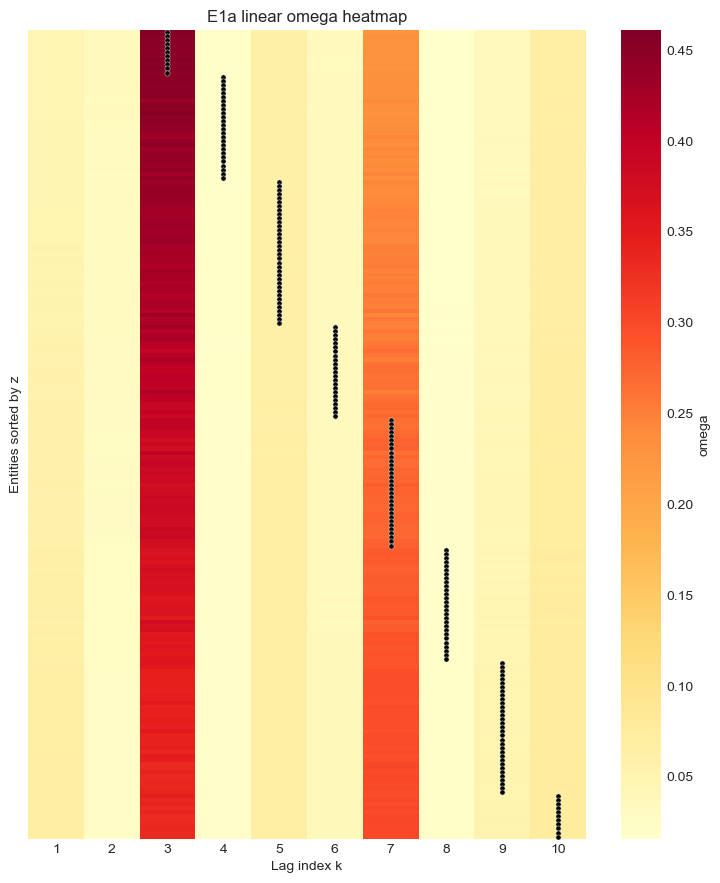

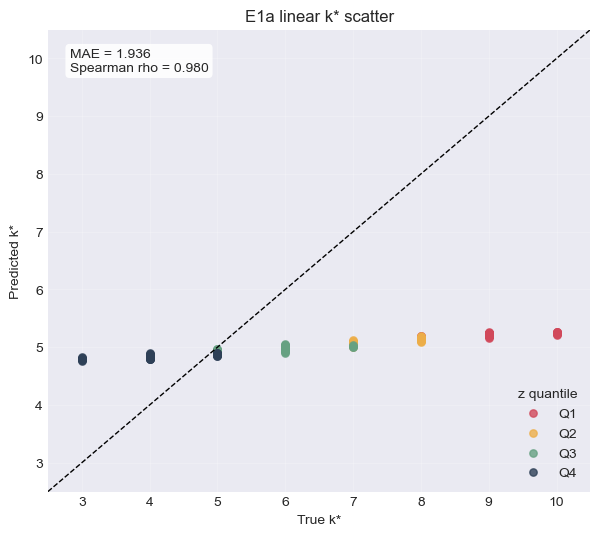

In [12]:
linear_predictions = load_predictions("E1a_linear")
if linear_predictions is None:
    raise FileNotFoundError("Missing E1a_linear/predictions.csv. Please run the experiment cell first.")

display(
    linear_predictions[["entity_id", "z_true", "z_pred", "kstar_true", "kstar_pred", "omega_peak"]].head()
 )

# Keep only omega_1 ... omega_K and exclude omega_peak. / 只保留 omega_1 到 omega_K，排除 omega_peak。
linear_omega_columns = sorted(
    [column for column in linear_predictions.columns if column.startswith("omega_") and column[6:].isdigit()],
    key=lambda name: int(name.split("_")[1]),
)
linear_omega = linear_predictions[linear_omega_columns].to_numpy()

# Re-render the saved outputs inline for notebook inspection. / 在 notebook 中重新渲染保存结果，方便直接查看。
linear_heatmap_ax = plot_omega_heatmap(
    linear_omega,
    linear_predictions["z_true"].to_numpy(),
    linear_predictions["kstar_true"].to_numpy(),
    save_path=None,
)
linear_heatmap_ax.set_title("E1a linear omega heatmap")
plt.show()

linear_scatter_ax = plot_kstar_scatter(
    linear_predictions["kstar_pred"].to_numpy(),
    linear_predictions["kstar_true"].to_numpy(),
    save_path=None,
    z_values=linear_predictions["z_true"].to_numpy(),
)
linear_scatter_ax.set_title("E1a linear k* scatter")
plt.show()

,entity_id,z_true,z_pred,kstar_true,kstar_pred,omega_peak
0,0,0.773956,0.683651,1.0,3.959842,3
1,1,0.438878,0.622679,3.0,4.014185,3
2,2,0.858598,0.690363,1.0,3.954210,3
3,3,0.697368,0.676756,1.0,3.965698,3
4,4,0.094177,0.505410,8.0,4.135320,3


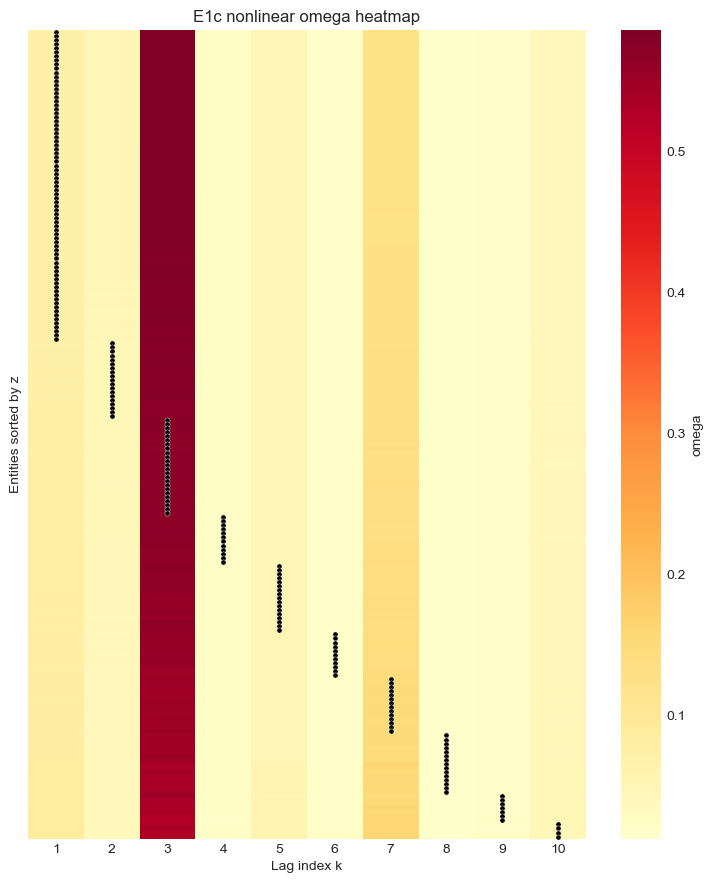

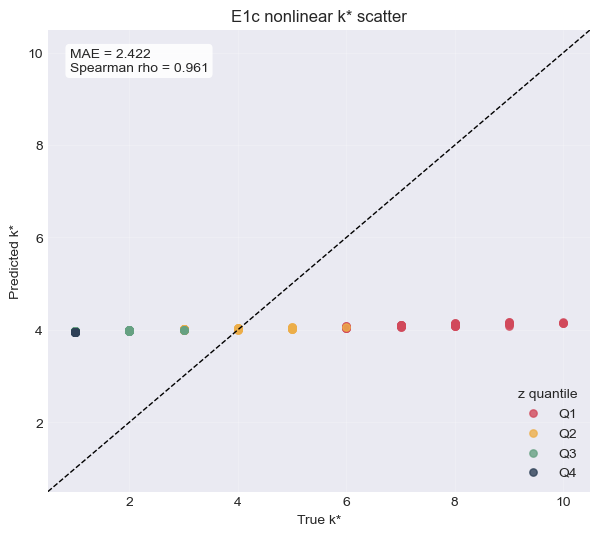

,experiment,scenario,kstar_mae,kstar_spearman_rho,proxy_recon_r2,omega_entropy_mean,omega_peak_accuracy
0,E1a_linear,linear,1.935703,0.979620,-21.466903,1.754083,0.055
1,E1c_nonlinear,nonlinear,2.421832,0.960851,-19.464733,1.519784,0.120


In [13]:
nonlinear_predictions = load_predictions("E1c_nonlinear")

if nonlinear_predictions is None:
    print("Nonlinear experiment was not executed. / 当前未执行非线性实验。")
else:
    display(
        nonlinear_predictions[["entity_id", "z_true", "z_pred", "kstar_true", "kstar_pred", "omega_peak"]].head()
    )

    # Keep only omega_1 ... omega_K and exclude omega_peak. / 只保留 omega_1 到 omega_K，排除 omega_peak。
    nonlinear_omega_columns = sorted(
        [column for column in nonlinear_predictions.columns if column.startswith("omega_") and column[6:].isdigit()],
        key=lambda name: int(name.split("_")[1]),
    )
    nonlinear_omega = nonlinear_predictions[nonlinear_omega_columns].to_numpy()

    nonlinear_heatmap_ax = plot_omega_heatmap(
        nonlinear_omega,
        nonlinear_predictions["z_true"].to_numpy(),
        nonlinear_predictions["kstar_true"].to_numpy(),
        save_path=None,
    )
    nonlinear_heatmap_ax.set_title("E1c nonlinear omega heatmap")
    plt.show()

    nonlinear_scatter_ax = plot_kstar_scatter(
        nonlinear_predictions["kstar_pred"].to_numpy(),
        nonlinear_predictions["kstar_true"].to_numpy(),
        save_path=None,
        z_values=nonlinear_predictions["z_true"].to_numpy(),
    )
    nonlinear_scatter_ax.set_title("E1c nonlinear k* scatter")
    plt.show()

comparison_rows = []
for payload in [linear_summary, nonlinear_summary]:
    if payload is None:
        continue
    comparison_rows.append(
        {
            "experiment": payload["experiment"],
            "scenario": payload["scenario"],
            "kstar_mae": payload["metrics"].get("kstar_mae"),
            "kstar_spearman_rho": payload["metrics"].get("kstar_spearman_rho"),
            "proxy_recon_r2": payload["metrics"].get("proxy_recon_r2"),
            "omega_entropy_mean": payload["metrics"].get("omega_entropy_mean"),
            "omega_peak_accuracy": payload["metrics"].get("omega_peak_accuracy"),
        }
    )

comparison_frame = pd.DataFrame(comparison_rows)
display(comparison_frame)

## Debug Diagnostics / 调试诊断

This section checks whether the current Step 4 failures come from a training issue, a synthetic-data identifiability issue, or a model-design mismatch.
本节用于区分当前 Step 4 失败究竟来自训练问题、合成数据可识别性问题，还是模型设计与数据生成不匹配。

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from config.cmdl_config import CMDLConfig
from data.synthetic.generate import generate_cmdl_synthetic


# Diagnose whether proxy reconstruction is limited by the data-generator design or by the trained model. / 区分 proxy 重构问题来自数据生成设计还是训练后的模型。
debug_cfg = CMDLConfig.from_domain("synthetic", scenario="linear", seed=42)
debug_panel = generate_cmdl_synthetic(debug_cfg)

proxy_true_columns = [column for column in linear_predictions.columns if column.startswith("proxy_") and column.endswith("_true")]
proxy_true = linear_predictions[proxy_true_columns].to_numpy()
z_pred = linear_predictions[["z_pred"]].to_numpy()
z_true = linear_predictions[["z_true"]].to_numpy()

best_linear_from_z_true = LinearRegression().fit(z_true, proxy_true).predict(z_true)
best_linear_from_z_pred = LinearRegression().fit(z_pred, proxy_true).predict(z_pred)

proxy_debug_table = pd.DataFrame(
    [
        {
            "diagnostic": "best_linear_proxy_r2_from_z_true",
            "value": r2_score(proxy_true, best_linear_from_z_true, multioutput="uniform_average"),
        },
        {
            "diagnostic": "best_linear_proxy_r2_from_z_pred",
            "value": r2_score(proxy_true, best_linear_from_z_pred, multioutput="uniform_average"),
        },
        {
            "diagnostic": "model_proxy_recon_r2",
            "value": extract_metric(e1b_summary, "proxy_recon_r2"),
        },
    ]
)

# Diagnose whether lagged inputs are highly collinear across lag positions. / 检查不同 lag 的输入是否高度共线。
x_values = debug_panel.X_it.squeeze(-1).detach().cpu().numpy()
lag_series = [
    x_values[:, debug_cfg.max_lag - lag : debug_cfg.seq_length - lag].reshape(-1)
    for lag in range(1, debug_cfg.max_lag + 1)
 ]
lag_corr = np.corrcoef(lag_series)
lag_corr_df = pd.DataFrame(
    lag_corr,
    index=[f"lag_{lag}" for lag in range(1, debug_cfg.max_lag + 1)],
    columns=[f"lag_{lag}" for lag in range(1, debug_cfg.max_lag + 1)],
)
mean_abs_offdiag_corr = (np.abs(lag_corr).sum() - np.abs(np.diag(lag_corr)).sum()) / (lag_corr.size - len(lag_corr))

# Summarize the learned peak locations to confirm mode collapse around a few lags. / 汇总学习到的峰值位置，确认是否塌缩到少数 lag。
linear_peak_counts = linear_predictions["omega_peak"].value_counts().sort_index()
nonlinear_peak_counts = nonlinear_predictions["omega_peak"].value_counts().sort_index() if nonlinear_predictions is not None else pd.Series(dtype=int)

peak_debug_table = pd.DataFrame(
    {
        "linear_peak_count": linear_peak_counts,
        "nonlinear_peak_count": nonlinear_peak_counts,
    }
).fillna(0).astype(int)
peak_debug_table.index.name = "omega_peak"

display(proxy_debug_table)
display(pd.DataFrame([{
    "diagnostic": "mean_abs_offdiag_lag_corr",
    "value": mean_abs_offdiag_corr,
}]))
display(lag_corr_df.round(3))
display(peak_debug_table)

if proxy_debug_table.loc[proxy_debug_table["diagnostic"] == "best_linear_proxy_r2_from_z_true", "value"].item() < 0.5:
    print("Proxy reconstruction ceiling is already low with a linear map from z_true, so the generator/head pair is mismatched.")
    print("即使直接用 z_true 做线性重构，proxy R2 上限也偏低，说明当前生成器与线性重构头存在结构不匹配。")

if mean_abs_offdiag_corr > 0.5:
    print("Lagged inputs are strongly correlated across k, so k* is only weakly identifiable from the task loss alone.")
    print("不同 lag 的输入高度相关，因此仅靠任务损失时，k* 的可识别性会偏弱。")

,diagnostic,value
0,best_linear_proxy_r2_from_z_true,0.939191
1,best_linear_proxy_r2_from_z_pred,0.945816
2,model_proxy_recon_r2,-21.466903


,diagnostic,value
0,mean_abs_offdiag_lag_corr,0.308545


,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7,lag_8,lag_9,lag_10
lag_1,1.000,0.660,0.429,0.280,0.201,0.140,0.108,0.088,0.064,0.047
lag_2,0.660,1.000,0.659,0.426,0.276,0.195,0.142,0.110,0.088,0.067
lag_3,0.429,0.659,1.000,0.654,0.416,0.268,0.193,0.143,0.108,0.090
lag_4,0.280,0.426,0.654,1.000,0.650,0.409,0.262,0.195,0.143,0.107
lag_5,0.201,0.276,0.416,0.650,1.000,0.649,0.409,0.266,0.198,0.144
lag_6,0.140,0.195,0.268,0.409,0.649,1.000,0.652,0.415,0.271,0.203
lag_7,0.108,0.142,0.193,0.262,0.409,0.652,1.000,0.652,0.413,0.273
lag_8,0.088,0.110,0.143,0.195,0.266,0.415,0.652,1.000,0.648,0.415
lag_9,0.064,0.088,0.108,0.143,0.198,0.271,0.413,0.648,1.000,0.658
lag_10,0.047,0.067,0.090,0.107,0.144,0.203,0.273,0.415,0.658,1.000


,linear_peak_count,nonlinear_peak_count
omega_peak,,
3,200,200


## Debug Sweep / 调参诊断

This sweep keeps the model code unchanged and checks whether the current failure is mostly caused by lag-gate settings or by the reconstruction weight.
该诊断在不改模型代码的前提下，检查当前失败主要来自 lag gate 参数，还是来自重构损失权重。

In [ ]:
from copy import deepcopy

debug_output_root = repo_root / "outputs" / "notebook_step4" / "debug_sweeps"
debug_output_root.mkdir(parents=True, exist_ok=True)

debug_configs = [
    {"name": "baseline_60", "epochs": 60, "patience": 15, "lambda_r": 0.1, "temperature": 1.0, "lag_bias_strength": 1.0},
    {"name": "sharp_gate", "epochs": 60, "patience": 15, "lambda_r": 0.1, "temperature": 0.3, "lag_bias_strength": 0.1},
    {"name": "recon_focus", "epochs": 60, "patience": 15, "lambda_r": 1.0, "temperature": 1.0, "lag_bias_strength": 1.0},
    {"name": "combined", "epochs": 60, "patience": 15, "lambda_r": 1.0, "temperature": 0.3, "lag_bias_strength": 0.1},
]

debug_rows = []
for config in debug_configs:
    debug_args_dict = deepcopy(COMMON_ARGS)
    debug_args_dict.update(
        {
            "scenario": "linear",
            "epochs": config["epochs"],
            "patience": config["patience"],
            "lambda_r": config["lambda_r"],
            "temperature": config["temperature"],
            "lag_bias_strength": config["lag_bias_strength"],
            "log_every": 20,
            "output_dir": str(debug_output_root / config["name"]),
        }
    )
    debug_args = Namespace(**debug_args_dict)
    debug_linear_result = run_e1a(debug_args)
    debug_e1b_summary = run_e1b(debug_args, debug_linear_result)
    debug_predictions = pd.read_csv(Path(debug_args.output_dir) / "E1a_linear" / "predictions.csv")

    debug_rows.append(
        {
            "name": config["name"],
            "epochs": config["epochs"],
            "lambda_r": config["lambda_r"],
            "temperature": config["temperature"],
            "lag_bias_strength": config["lag_bias_strength"],
            "kstar_mae": debug_linear_result.metrics["kstar_mae"],
            "kstar_spearman_rho": debug_linear_result.metrics["kstar_spearman_rho"],
            "omega_peak_accuracy": debug_linear_result.metrics["omega_peak_accuracy"],
            "omega_entropy_mean": debug_linear_result.metrics["omega_entropy_mean"],
            "proxy_recon_r2": debug_e1b_summary["metrics"]["proxy_recon_r2"],
            "z_spearman_rho": debug_e1b_summary["metrics"]["z_spearman_rho"],
            "unique_omega_peaks": int(debug_predictions["omega_peak"].nunique()),
            "min_omega_peak": int(debug_predictions["omega_peak"].min()),
            "max_omega_peak": int(debug_predictions["omega_peak"].max()),
        }
    )

debug_sweep_table = pd.DataFrame(debug_rows).sort_values(["kstar_mae", "proxy_recon_r2"], ascending=[True, False])
display(debug_sweep_table)